In [166]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# A. EDA

# 1.Genel Resim

In [167]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 2.Numerik ve Kategorik Değişkenleri Yakalama

In [168]:
cat_cols = [col for col in df.columns if df[col].dtype not in ["int", "float"]]
print(cat_cols)
num_but_cat = [col for col in df.columns if df[col].nunique() <= 20]
print(num_but_cat)
cat_cols = cat_cols + num_but_cat
print(cat_cols)
num_cols = [col for col in df.columns if col not in cat_cols]
print(num_cols)




[]
['Pregnancies', 'Outcome']
['Pregnancies', 'Outcome']
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


# 3.Numerik ve Kategorik Değişkenlerin Analizi

In [169]:
def cat_summary(dataframe, col):
    print(pd.DataFrame({col: dataframe[col].value_counts(),
                "Ratio" : 100 * dataframe[col].value_counts() / len(dataframe)}))


for col in cat_cols:
    cat_summary(df, col)

             Pregnancies      Ratio
Pregnancies                        
1                    135  17.578125
0                    111  14.453125
2                    103  13.411458
3                     75   9.765625
4                     68   8.854167
5                     57   7.421875
6                     50   6.510417
7                     45   5.859375
8                     38   4.947917
9                     28   3.645833
10                    24   3.125000
11                    11   1.432292
13                    10   1.302083
12                     9   1.171875
14                     2   0.260417
17                     1   0.130208
15                     1   0.130208
         Outcome      Ratio
Outcome                    
0            500  65.104167
1            268  34.895833


number of unique values:  136
count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64


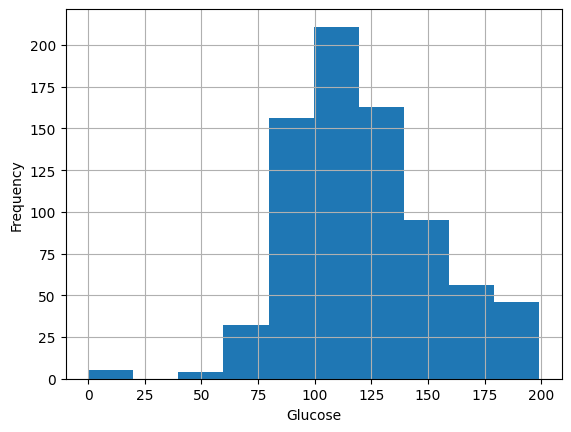

number of unique values:  47
count    768.000000
mean      69.105469
std       19.355807
min        0.000000
25%       62.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64


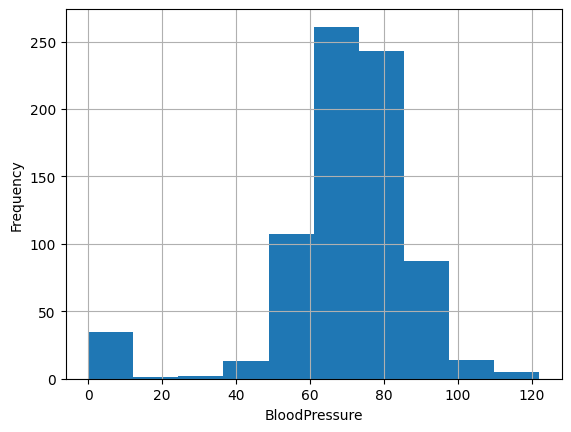

number of unique values:  51
count    768.000000
mean      20.536458
std       15.952218
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64


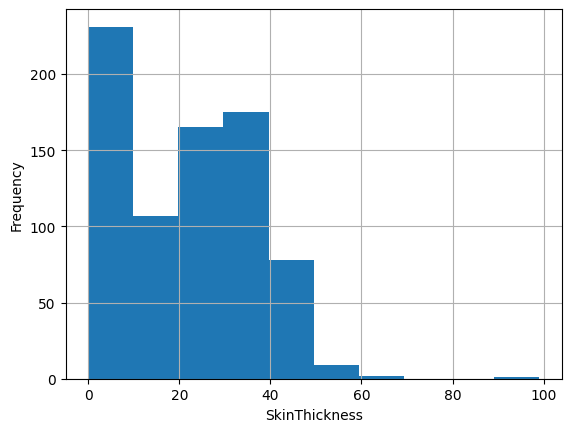

number of unique values:  186
count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64


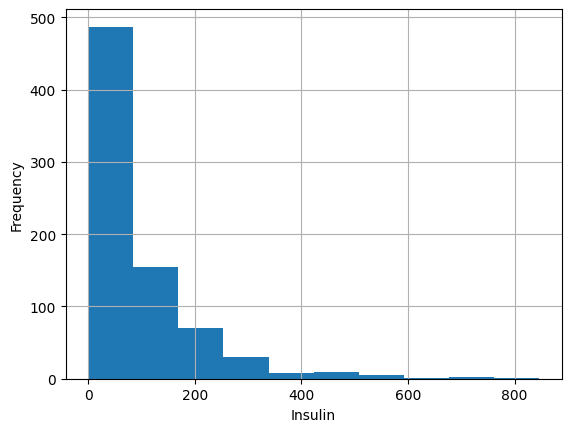

number of unique values:  248
count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64


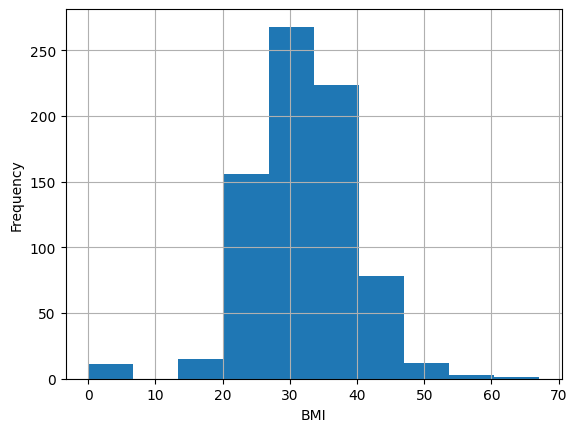

number of unique values:  517
count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64


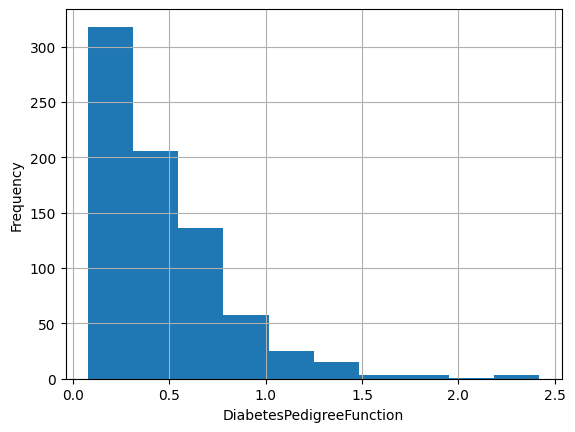

number of unique values:  52
count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64


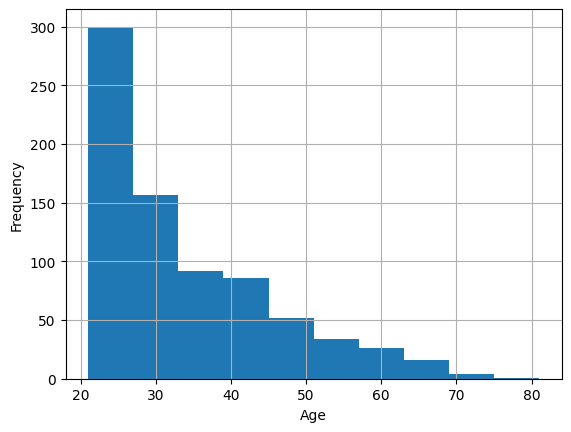

In [170]:
def num_summary(dataframe, col, plot=True):
    print("number of unique values: ", dataframe[col].nunique())
    print(dataframe[col].describe().T)

    if plot==True:
        dataframe[col].hist()
        plt.ylabel("Frequency")
        plt.xlabel(col)
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

# 4.Hedef Değişken Analizi

## 4.1 Kategorik Değişkenlerin Hedef Değişkenle Analizi

In [171]:
df.groupby("Pregnancies").agg({"Outcome": "mean"})

,Outcome
Pregnancies,
0,0.342342
1,0.214815
2,0.184466
3,0.360000
4,0.338235
5,0.368421
6,0.320000
7,0.555556
8,0.578947


**sonuç**: hamilelik sayısı arttıkça diyabete yakalanma ihtimali artmakta diyebiliriz

## 4.2 Numeric Değişkenlerin Hedef Değişkenle Analizi

In [172]:
def target_num_analysis(dataframe, target, col):
    print(dataframe.groupby(target).agg({col: "mean"}))

for col in num_cols:
    target_num_analysis(df, "Outcome", col)

            Glucose
Outcome            
0        109.980000
1        141.257463
         BloodPressure
Outcome               
0            68.184000
1            70.824627
         SkinThickness
Outcome               
0            19.664000
1            22.164179
            Insulin
Outcome            
0         68.792000
1        100.335821
               BMI
Outcome           
0        30.304200
1        35.142537
         DiabetesPedigreeFunction
Outcome                          
0                        0.429734
1                        0.550500
               Age
Outcome           
0        31.190000
1        37.067164


**sonuçlar:**
*diyabete yakalanma ihtimalini artıranlar*

1-Vücuttaki glukoz miktarı

2-Yaş

3-Deri kalınlığı 


# 5. Aykırı Gözlem Analizi (outliers)

Note: Ayrkırı değerler üzerinde oynama yoktur, aykırı değerler **yalnızca incelenmiştir.**

## 5.1 boxplot yöntemi

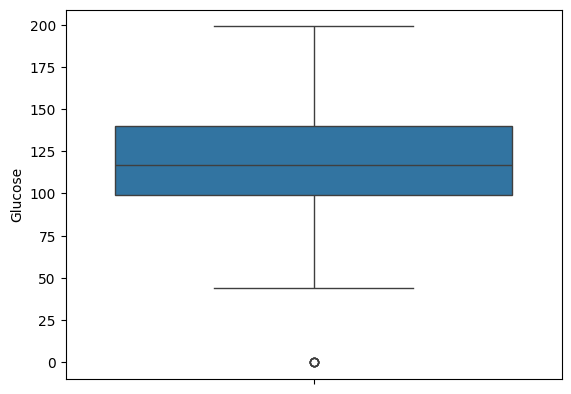

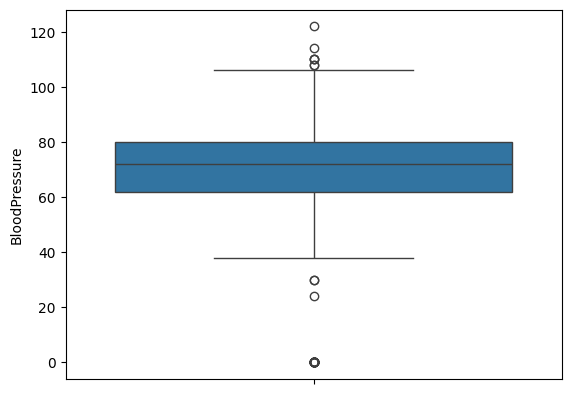

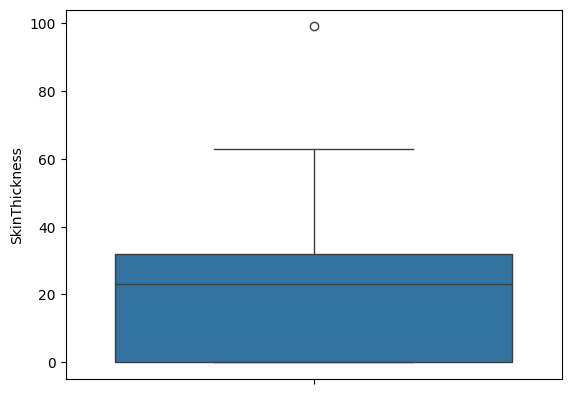

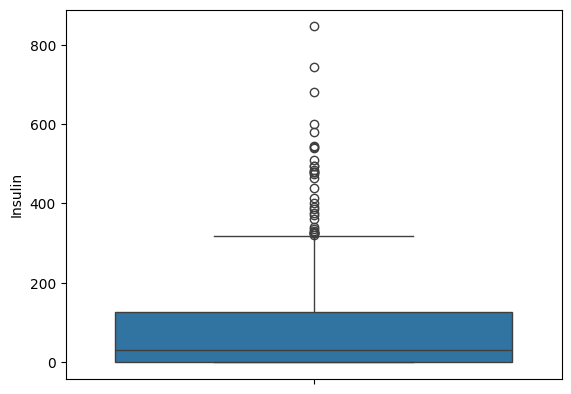

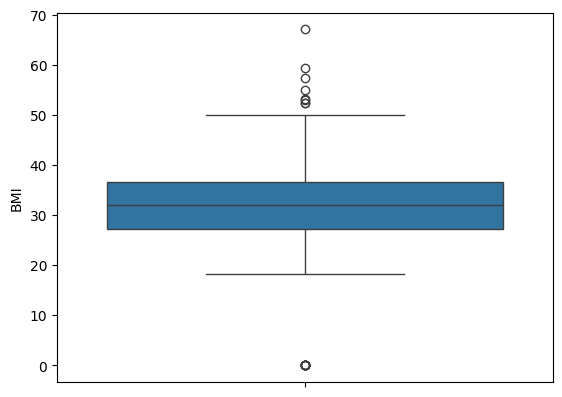

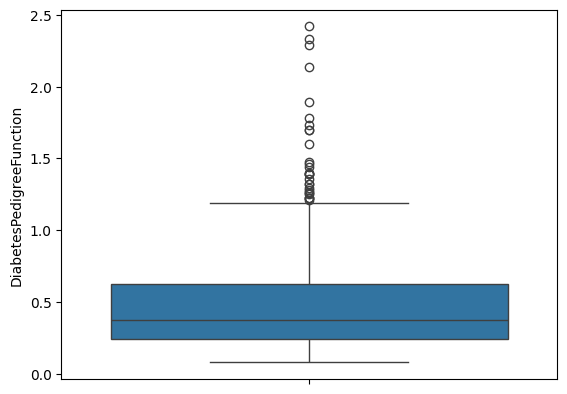

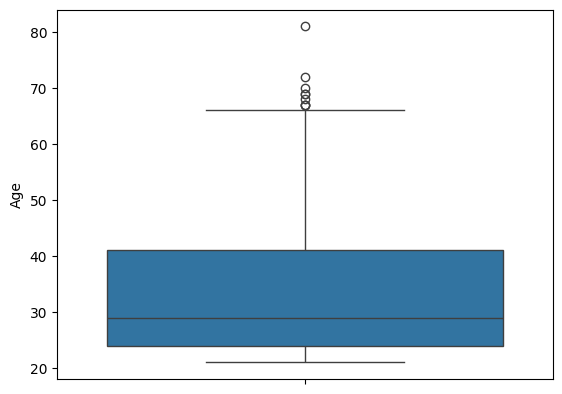

In [173]:
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

## 5.2 manuel yöntem

### 5.2.1 lower(min) ve upper(max) değerlerini belirleme

In [174]:
def outliers_threshold(dataframe, col, q1=0.25, q3=0.75):
    quartile1 = dataframe[col].quantile(q1)
    quartile3 = dataframe[col].quantile(q3)
    ICR = q3 - q1
    lower_limit = quartile1 - 1.5*ICR
    upper_limit = quartile3 + 1.5*ICR
    return lower_limit, upper_limit

### 5.2.2 aykırı değer var mı yok mu?

In [175]:
def check_outlier(dataframe, col):
    lower, upper = outliers_threshold(dataframe, col)
    flag = dataframe[(dataframe[col]<lower) | (dataframe[col]>upper)].any(axis=None)
    if flag:
        return True
    else:
        return False

for col in num_cols:
    print(col, check_outlier(df, col))

Glucose True
BloodPressure True
SkinThickness True
Insulin True
BMI True
DiabetesPedigreeFunction True
Age True


### 5.2.3 sütunların içerdiği aykırı değer oranları ve sayıları

In [176]:
def print_number_of(dataframe, col):
    low, up = outliers_threshold(df, col)
    print(f"{col} için aykırı değer: ", len(dataframe[(dataframe[col]<low) | (dataframe[col]>up)].index))
    print("ilgili sütunun toplam değeri: ", len(dataframe[col].index))
    print("İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI")
    # to do: aykırı değer, toplam değer ve bunların yüzdelik 
    # oranları groupby kullanarak bir dataframe'e kaydet. 
    # Bir yerde örnek kodu var ama nerde ?
    per = len(dataframe[(dataframe[col]<low) | (dataframe[col]>up)].index) * 100 / len(dataframe[col].index)
    print("----------------------------------------------------------")

for col in num_cols:
    print_number_of(df, col)

Glucose için aykırı değer:  367
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
BloodPressure için aykırı değer:  324
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
SkinThickness için aykırı değer:  188
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
Insulin için aykırı değer:  191
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
BMI için aykırı değer:  343
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
DiabetesPedigreeFunction için aykırı değer:  17
ilgili sütunun toplam değeri:  768
İLGİLİ SÜTUNUN AYKIRI DEĞER ORANI
----------------------------------------------------------
Age için aykırı 

## 5.3 Aykırı Değerlere Erişmek

In [177]:
def grab_outliers(dataframe, col_name, index=False):
    low, up = outliers_threshold(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

grab_outliers(df, "Age")
age_index = grab_outliers(df, "Age", True)
print(age_index)

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
3             1       89             66             23       94  28.1   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
12           10      139             80              0        0  27.1   

    DiabetesPedigreeFunction  Age  Outcome  
0                      0.627   50        1  
3                      0.167   21        0  
8                      0.158   53        1  
9                      0.232   54        1  
12                     1.441   57        0  
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
3             1       89             66             23       94  28.1   
8             2      197             70             45      543  30.5   

# 6. Eksik Gözlem Analizi

In [178]:
df.isnull().sum() # eksik gözlem yok lakin bazı glikoz ve insulin 
                # değerleri 0 olarak atanmış bunları nan'a çevirip 
                # sonra tekrar dolduracağız. İleride...

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# 7. Korelasyon Analizi

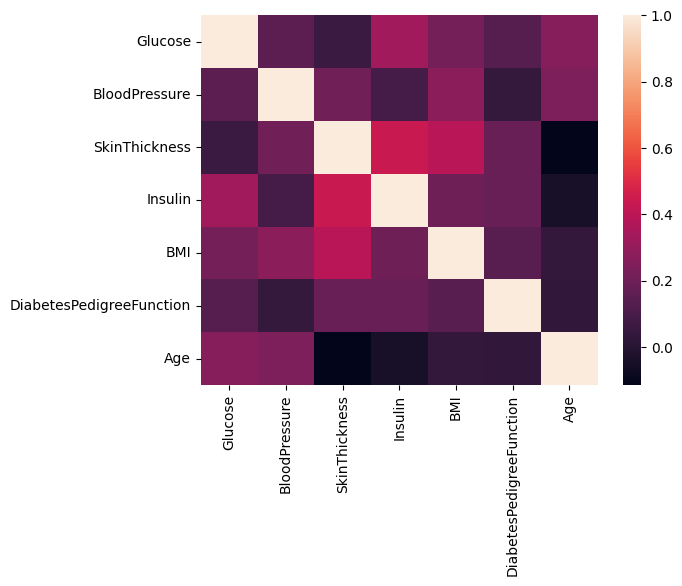

In [179]:
corr = df[num_cols].corr()
sns.heatmap(corr)
plt.show()

# B. FEATURE ENGINEERING

## 1. Veri Setine Özel Durum

Insulin ve Glikoz değerlerini NaN ile değiştirip tekrar dolduruyoruz.

In [180]:
df[['Glucose', 'Insulin']]

,Glucose,Insulin
0,148,0
1,85,0
2,183,0
3,89,94
4,137,168
...,...,...
763,101,180
764,122,0
765,121,112
766,126,0


In [181]:
df_with_nan = df[['Glucose', 'Insulin']].replace(to_replace=0, value=np.nan)

In [182]:
df_with_nan.isnull().sum()

Glucose      5
Insulin    374
dtype: int64

In [183]:
def fillna_mean(dataframe, col):
    dataframe[col] = dataframe[col].fillna(df[col].mean())

for col in ['Glucose', 'Insulin']:
    fillna_mean(df, col)

## 2. Oluşturulabilecek Yeni Değişkenler

In [184]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2.1 Age grouping

In [185]:
df['Age_cat'] = pd.cut(df.Age, bins=[20,28,45,60,81], labels=['genç','orta yaş','az yaşlı', 'yaşlı'])

### 2.2 Age ve BMI ilişkisi

In [186]:
df['Age_BMI'] = df['Age'] * df['BMI']

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   Age_cat                   768 non-null    category
 10  Age_BMI                   768 non-null    float64 
dtypes: category(1), float64(3), int64(7)
memory usage: 61.1 KB


In [188]:
from sklearn.model_selection import train_test_split
y = df.iloc[:,8]
X = df.drop(columns=df.columns[8])

## 3. Encoding

In [189]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Age_cat'] = le.fit_transform(df['Age_cat'])

In [190]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_cat,Age_BMI
0,6,148,72,35,0,33.6,0.627,50,1,0,1680.0
1,1,85,66,29,0,26.6,0.351,31,0,2,824.6
2,8,183,64,0,0,23.3,0.672,32,1,2,745.6
3,1,89,66,23,94,28.1,0.167,21,0,1,590.1
4,0,137,40,35,168,43.1,2.288,33,1,2,1422.3


## 4. train test split

In [191]:
from sklearn.model_selection import train_test_split
y = df.iloc[:,8]
X = df.drop(columns=df.columns[8])

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

## 5. Scaling

In [193]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_df_scaled = ss.fit_transform(X)
X_df_scaled = pd.DataFrame(X_df_scaled)
X_df_scaled

,0,1,2,3,4,5,6,7,8,9
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,-1.822197,1.356353
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0.938054,-0.535783
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,0.938054,-0.710530
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,-0.442072,-1.054495
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,0.938054,0.786324
...,...,...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136,2.318180,2.225002
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023,-0.442072,-0.161957
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760,0.938054,-0.621166
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732,-1.822197,0.769512


# C. Model creating

## 1. model selection

In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. logistic regression model

In [ ]:

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Predict probability scores (optional)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1


c:\Users\umuta\OneDrive\Desktop\Yazilim\dataAnalaysing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# (Precision, Recall, F1-score)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.73
Confusion Matrix:
 [[83 16]
 [26 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      0.80        99
           1       0.64      0.53      0.58        55

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154

